<a href="https://colab.research.google.com/github/asternoeld/practical-ml-25-26/blob/main/assignment2/assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
# Assignment 2 - Practical Machine Learning
# Student: Aster Noel Dsouza
# Dataset: Aquifer Petrignano

# Assignment 2: Groundwater Prediction using Time Series Cross-Validation

This notebook predicts `Depth_to_Groundwater_P25` using previous monthly values of all variables.

The assignment compares:

- Standard KFold cross-validation
- TimeSeriesSplit cross-validation

The goal is to show why time-aware validation is more reliable for temporal datasets.

In [44]:
# prompt: import python libraries required for regression, preprocessing and cross validation

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.model_selection import cross_val_score, GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import r2_score

In [45]:
url = "https://raw.githubusercontent.com/asternoeld/practical-ml-25-26/main/assignment2/Petrignano.csv"

df = pd.read_csv(url)

print(df.shape)
df.head()

(4199, 7)


,Date,Rainfall_Bastia_Umbra,Depth_to_Groundwater_P25,Temperature_Bastia_Umbra,Temperature_Petrignano,Volume_C10_Petrignano,Hydrometry_Fiume_Chiascio_Petrignano
0,1/1/2009,0.0,-31.14,5.2,4.9,-24530.688,2.4
1,2/1/2009,0.0,-31.11,2.3,2.5,-28785.888,2.5
2,3/1/2009,0.0,-31.07,4.4,3.9,-25766.208,2.4
3,4/1/2009,0.0,-31.05,0.8,0.8,-27919.296,2.4
4,5/1/2009,0.0,-31.01,-1.9,-2.1,-29854.656,2.3


## Data Preparation

The original dataset contains daily observations.  
Since the task requires monthly prediction using the previous two months, the data is aggregated to monthly frequency.

Missing values are handled before feature engineering.

In [46]:
# Check column names
print(df.columns.tolist())

['Date', 'Rainfall_Bastia_Umbra', 'Depth_to_Groundwater_P25', 'Temperature_Bastia_Umbra', 'Temperature_Petrignano', 'Volume_C10_Petrignano', 'Hydrometry_Fiume_Chiascio_Petrignano']


In [47]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Sort chronologically
df = df.sort_values('Date')

# Check missing values
df.isnull().sum()

,0
Date,0
Rainfall_Bastia_Umbra,0
Depth_to_Groundwater_P25,27
Temperature_Bastia_Umbra,0
Temperature_Petrignano,0
Volume_C10_Petrignano,1
Hydrometry_Fiume_Chiascio_Petrignano,0


## Missing Value Treatment and Monthly Aggregation

The dataset contains a small number of missing values.  
Linear interpolation is used because it preserves the time-series continuity.

The daily observations are then converted into monthly averages to match the assignment objective.

In [48]:
# prompt: clean missing values using interpolation and convert daily data to monthly averages

# Make a copy
df_clean = df.copy()

# Set Date as index
df_clean = df_clean.set_index('Date')

# Interpolate missing values
df_clean = df_clean.interpolate(method='linear')

# Confirm missing values removed
print(df_clean.isnull().sum())

# Convert daily data to monthly averages
df_monthly = df_clean.resample('ME').mean()

print("Monthly shape:", df_monthly.shape)

df_monthly.head()

Rainfall_Bastia_Umbra                   0
Depth_to_Groundwater_P25                0
Temperature_Bastia_Umbra                0
Temperature_Petrignano                  0
Volume_C10_Petrignano                   0
Hydrometry_Fiume_Chiascio_Petrignano    0
dtype: int64
Monthly shape: (138, 6)


,Rainfall_Bastia_Umbra,Depth_to_Groundwater_P25,Temperature_Bastia_Umbra,Temperature_Petrignano,Volume_C10_Petrignano,Hydrometry_Fiume_Chiascio_Petrignano
Date,,,,,,
2009-01-31,0.203226,-30.503871,4.964516,4.945161,-26695.119484,2.387097
2009-02-28,0.500000,-29.350000,5.125000,4.792857,-25641.174857,2.546429
2009-03-31,1.103226,-28.502903,9.254839,8.716129,-28374.874839,2.490323
2009-04-30,0.543333,-27.736333,13.806667,13.250000,-28167.667200,2.403333
2009-05-31,0.922581,-27.478065,19.809677,18.812903,-32187.288774,2.109677


## Time Series Visualization

A line graph is used to inspect long-term trend and seasonal movement in groundwater depth.  
This helps confirm that the observations are sequential and should be validated using time-aware methods.

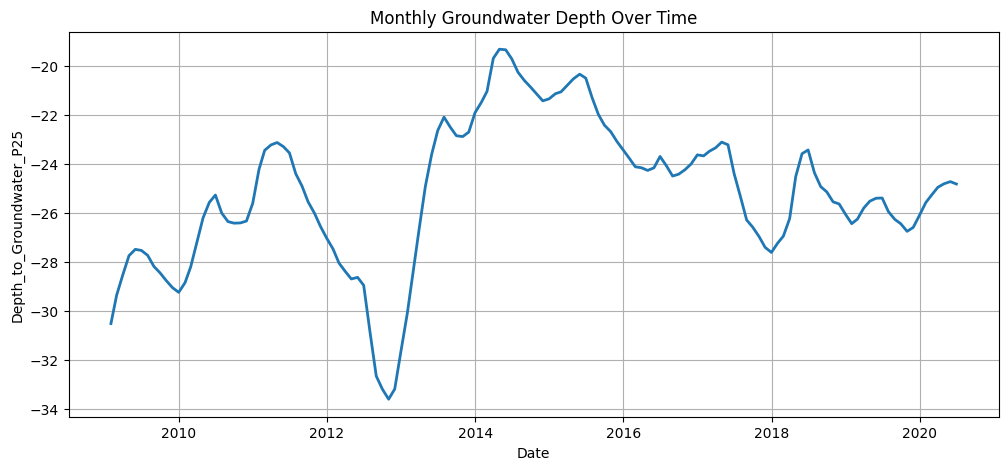

In [49]:
# prompt: create a simple time-series graph of monthly groundwater depth

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    df_monthly.index,
    df_monthly["Depth_to_Groundwater_P25"],
    linewidth=2
)

plt.title("Monthly Groundwater Depth Over Time")
plt.xlabel("Date")
plt.ylabel("Depth_to_Groundwater_P25")
plt.grid(True)

plt.show()

## Feature Engineering

To predict the current month's groundwater level, lag variables are created using the previous two months.

For example:

- March prediction uses January and February information.

In [50]:
# prompt: create lag1 and lag2 features from monthly time-series variables
# modified: added month variable for seasonality

# Create lagged dataset
df_lagged = df_monthly.copy()

for col in df_monthly.columns:
    df_lagged[f"{col}_lag1"] = df_monthly[col].shift(1)
    df_lagged[f"{col}_lag2"] = df_monthly[col].shift(2)

# Optional seasonality feature
df_lagged["month"] = df_lagged.index.month

# Remove rows with missing lag values
df_lagged = df_lagged.dropna()

print("Lagged dataset shape:", df_lagged.shape)

df_lagged.head()

Lagged dataset shape: (136, 19)


,Rainfall_Bastia_Umbra,Depth_to_Groundwater_P25,Temperature_Bastia_Umbra,Temperature_Petrignano,Volume_C10_Petrignano,Hydrometry_Fiume_Chiascio_Petrignano,Rainfall_Bastia_Umbra_lag1,Rainfall_Bastia_Umbra_lag2,Depth_to_Groundwater_P25_lag1,Depth_to_Groundwater_P25_lag2,Temperature_Bastia_Umbra_lag1,Temperature_Bastia_Umbra_lag2,Temperature_Petrignano_lag1,Temperature_Petrignano_lag2,Volume_C10_Petrignano_lag1,Volume_C10_Petrignano_lag2,Hydrometry_Fiume_Chiascio_Petrignano_lag1,Hydrometry_Fiume_Chiascio_Petrignano_lag2,month
Date,,,,,,,,,,,,,,,,,,,
2009-03-31,1.103226,-28.502903,9.254839,8.716129,-28374.874839,2.490323,0.500000,0.203226,-29.350000,-30.503871,5.125000,4.964516,4.792857,4.945161,-25641.174857,-26695.119484,2.546429,2.387097,3
2009-04-30,0.543333,-27.736333,13.806667,13.250000,-28167.667200,2.403333,1.103226,0.500000,-28.502903,-29.350000,9.254839,5.125000,8.716129,4.792857,-28374.874839,-25641.174857,2.490323,2.546429,4
2009-05-31,0.922581,-27.478065,19.809677,18.812903,-32187.288774,2.109677,0.543333,1.103226,-27.736333,-28.502903,13.806667,9.254839,13.250000,8.716129,-28167.667200,-28374.874839,2.403333,2.490323,5
2009-06-30,0.010000,-27.522000,21.203333,20.273333,-31514.832000,2.053333,0.922581,0.543333,-27.478065,-27.736333,19.809677,13.806667,18.812903,13.250000,-32187.288774,-28167.667200,2.109677,2.403333,6
2009-07-31,0.058065,-27.721613,25.393548,24.287097,-32104.790710,2.058065,0.010000,0.922581,-27.522000,-27.478065,21.203333,19.809677,20.273333,18.812903,-31514.832000,-32187.288774,2.053333,2.109677,7


## Defining Predictors and Response Variable

The response variable is:

- `Depth_to_Groundwater_P25`

Predictors include:

- Previous two months of all variables
- Seasonal month indicator

In [51]:
# prompt: create response variable and predictors using previous two months only
# modified: selected lag variables only to match assignment requirement

# Response variable
y = df_lagged["Depth_to_Groundwater_P25"]

# Select lagged predictors only
lag_columns = [col for col in df_lagged.columns if "lag" in col]

# Add seasonal month variable
lag_columns.append("month")

X = df_lagged[lag_columns]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.columns.tolist())

X shape: (136, 13)
y shape: (136,)
['Rainfall_Bastia_Umbra_lag1', 'Rainfall_Bastia_Umbra_lag2', 'Depth_to_Groundwater_P25_lag1', 'Depth_to_Groundwater_P25_lag2', 'Temperature_Bastia_Umbra_lag1', 'Temperature_Bastia_Umbra_lag2', 'Temperature_Petrignano_lag1', 'Temperature_Petrignano_lag2', 'Volume_C10_Petrignano_lag1', 'Volume_C10_Petrignano_lag2', 'Hydrometry_Fiume_Chiascio_Petrignano_lag1', 'Hydrometry_Fiume_Chiascio_Petrignano_lag2', 'month']


In [52]:
# Hard chronological split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Train size:", X_train_full.shape)
print("Test size:", X_test.shape)

Train size: (108, 13)
Test size: (28, 13)


## Cross-Validation Comparison

Two strategies are evaluated:

1. **Naive KFold**  
   Randomly shuffles observations and may cause data leakage.

2. **TimeSeriesSplit**  
   Preserves time order and provides more realistic estimates.

In [53]:
# prompt: compare KFold and TimeSeriesSplit using decision tree regression
# modified: used R2 score and chronological holdout test set

# CV strategies
cv_naive = KFold(n_splits=5, shuffle=True, random_state=42)
cv_temporal = TimeSeriesSplit(n_splits=5)

# Fixed model pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', DecisionTreeRegressor(max_depth=10, random_state=42))
])

# Scores
scores_naive = cross_val_score(
    pipe, X_train_full, y_train_full,
    cv=cv_naive,
    scoring='r2'
)

scores_temporal = cross_val_score(
    pipe, X_train_full, y_train_full,
    cv=cv_temporal,
    scoring='r2'
)

print(f"Naive CV R2:    {scores_naive.mean():.4f} (+/- {scores_naive.std():.4f})")
print(f"Temporal CV R2: {scores_temporal.mean():.4f} (+/- {scores_temporal.std():.4f})")

# Final test score
pipe.fit(X_train_full, y_train_full)

final_test_r2 = r2_score(
    y_test,
    pipe.predict(X_test)
)

print(f"\nActual Test R2 on unseen future data: {final_test_r2:.4f}")

Naive CV R2:    0.9238 (+/- 0.0297)
Temporal CV R2: -0.2998 (+/- 1.5624)

Actual Test R2 on unseen future data: -0.6107


## Model Selection using GridSearchCV

Hyperparameter tuning is performed using the maximum tree depth.

This is compared using:

- Naive KFold
- TimeSeriesSplit

In [54]:
# prompt: tune decision tree max_depth using GridSearchCV
# modified: compared tuned model under both CV strategies

def evaluate_model_selection(X_train, y_train, X_test, y_test, cv_strategy, name):

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', DecisionTreeRegressor(random_state=42))
    ])

    param_grid = {
        'regressor__max_depth': [2, 3, 5, 10, 15, None]
    }

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=cv_strategy,
        scoring='r2'
    )

    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)

    print(f"\n===== {name} =====")
    print("Best Parameters:", grid.best_params_)
    print("Internal CV Score:", round(grid.best_score_, 4))
    print("Independent Test Score:", round(test_r2, 4))

    return grid

In [55]:
result_naive = evaluate_model_selection(
    X_train_full, y_train_full, X_test, y_test,
    cv_naive,
    "Naive KFold"
)

result_temporal = evaluate_model_selection(
    X_train_full, y_train_full, X_test, y_test,
    cv_temporal,
    "TimeSeriesSplit"
)


===== Naive KFold =====
Best Parameters: {'regressor__max_depth': 10}
Internal CV Score: 0.9238
Independent Test Score: -0.6107

===== TimeSeriesSplit =====
Best Parameters: {'regressor__max_depth': 10}
Internal CV Score: -0.2998
Independent Test Score: -0.6107


## Final Conclusion

This assignment compared standard KFold cross-validation with TimeSeriesSplit on a groundwater forecasting task.

The Naive KFold approach produced high internal validation scores but poor independent test performance, indicating data leakage caused by random shuffling of temporal observations.

TimeSeriesSplit produced lower validation scores, but it is more appropriate for time-series data because chronological order is preserved.

The model used predictors from the previous two months together with a seasonal month indicator to forecast Depth_to_Groundwater_P25.